## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : Wind Power Generation Forecasting

## Problem Statement

Predicting wind turbine power output is essential for grid stability, energy trading, and efficient renewable energy integration. This project aims to build a regression model that forecasts normalized turbine power output based on atmospheric conditions.

**Goal:** Develop an accurate predictive model for wind power generation using weather features (temperature, humidity, wind speed/direction at multiple heights).

**Approach:**
- Explore relationships between weather variables and power output
- Engineer temporal features (hour, month, season)
- Train regression models 
- Evaluate using RMSE, MAE, R²

**Audience:** Wind farm operators, energy grid managers, renewable energy stakeholders

## Data Info
**Source:** Kaggle - Wind Power Forecasting (Turbine data from 4 locations)
**Train set:** 140,160 rows × 11 features + target
**Test set:** 35,040 rows (no target — for prediction)
**Target Variable:** `Power` — normalized turbine power output (continuous, range 0–1)
**Problem Type:** Regression
**Data Frequency:** Hourly readings from 4 locations across multiple years

## Data Dictionary
| Column     | Type    | Description                                                |
|----------- | ------- | ---------------------------------------------------------- |
| Time       | datetime| Timestamp of reading (hourly)                              |
| Location   | int     | Location ID (1–4)                                          |
| Temp_2m    | float   | Temperature at 2m above surface (°C)                       |
| RelHum_2m  | float   | Relative humidity at 2m above surface (%)                  |
| DP_2m      | float   | Dew point at 2m above surface (°C)                         |
| WS_10m     | float   | Wind speed at 10m above surface (m/s)                      |
| WS_100m    | float   | Wind speed at 100m above surface (m/s)                     |
| WD_10m     | float   | Wind direction at 10m above surface (°)                    |
| WD_100m    | float   | Wind direction at 100m above surface (°)                   |
| WG_10m     | float   | Wind gust at 10m above surface (m/s)                       |
| **Power**  | float   | **TARGET:** Turbine power generation (normalized 0–1)      |

In [15]:
# Common imports for all topics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Imports loaded successfully")

Imports loaded successfully


In [16]:
# ═══════════════════════════════════════════════
# TOPIC 1: Wind Power Generation Forecasting
# ═══════════════════════════════════════════════

BASE_WIND = '/home/ultori/Downloads/motor Datasets/Wind powergen forecasting/archive(4)'

df_wind = pd.read_csv(f'{BASE_WIND}/Train.csv')
print(f'Shape: {df_wind.shape}')
df_wind.head(10)

Shape: (140160, 12)


,Unnamed: 0,Time,Location,Temp_2m,RelHum_2m,DP_2m,WS_10m,WS_100m,WD_10m,WD_100m,WG_10m,Power
0,0,02-01-2013 00:00,1,28.2796,84.664205,24.072595,1.605389,1.267799,145.051683,161.057315,1.336515,0.163496
1,1,02-01-2013 01:00,1,28.1796,85.664205,24.272595,2.225389,3.997799,150.051683,157.057315,4.336515,0.142396
2,2,02-01-2013 02:00,1,26.5796,90.664205,24.072595,1.465389,2.787799,147.051683,149.057315,3.136515,0.121396
3,3,02-01-2013 03:00,1,27.1796,87.664205,23.872595,1.465389,2.697799,57.051683,104.057315,1.536515,0.100296
4,4,02-01-2013 04:00,1,27.0796,87.664205,23.672595,2.635389,4.437799,57.051683,83.057315,3.936515,0.079296
5,5,02-01-2013 05:00,1,27.3796,89.664205,24.772595,2.895389,5.597799,65.051683,79.057315,4.436515,0.077796
6,6,02-01-2013 06:00,1,26.4796,91.664205,24.472595,2.265389,5.827799,64.051683,77.057315,4.636515,0.095896
7,7,02-01-2013 07:00,1,28.1796,90.664205,25.672595,3.265389,6.247799,68.051683,77.057315,4.736515,0.114096
8,8,02-01-2013 08:00,1,29.9796,87.664205,26.572595,3.705389,6.897799,73.051683,80.057315,5.736515,0.132196
9,9,02-01-2013 09:00,1,33.7796,81.664205,28.672595,3.605389,6.017799,81.051683,85.057315,6.436515,0.150296


=== TARGET: Power ===
Power represents normalized turbine power output (0 = no gen, 1 = max)
Type: Continuous (Regression problem)
count    140160.000000
mean          0.312437
std           0.253774
min          -0.000004
25%           0.099696
50%           0.246896
75%           0.486396
max           0.988796
Name: Power, dtype: float64


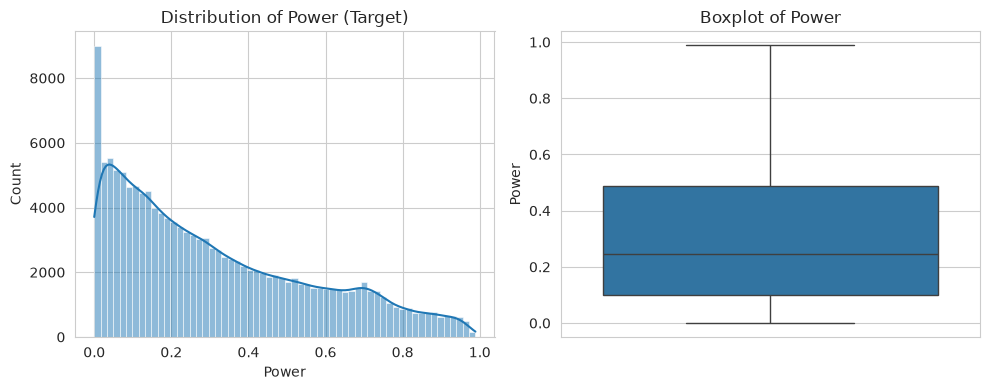

/tmp/ipykernel_20247/4012769125.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()



Categorical features (1): ['Time']
Numerical features (10): ['Location', 'Temp_2m', 'RelHum_2m', 'DP_2m', 'WS_10m', 'WS_100m', 'WD_10m', 'WD_100m', 'WG_10m', 'Power']
  → Location has 4 unique values, treat as categorical

=== NULL VALUES ===
No null values in any column!


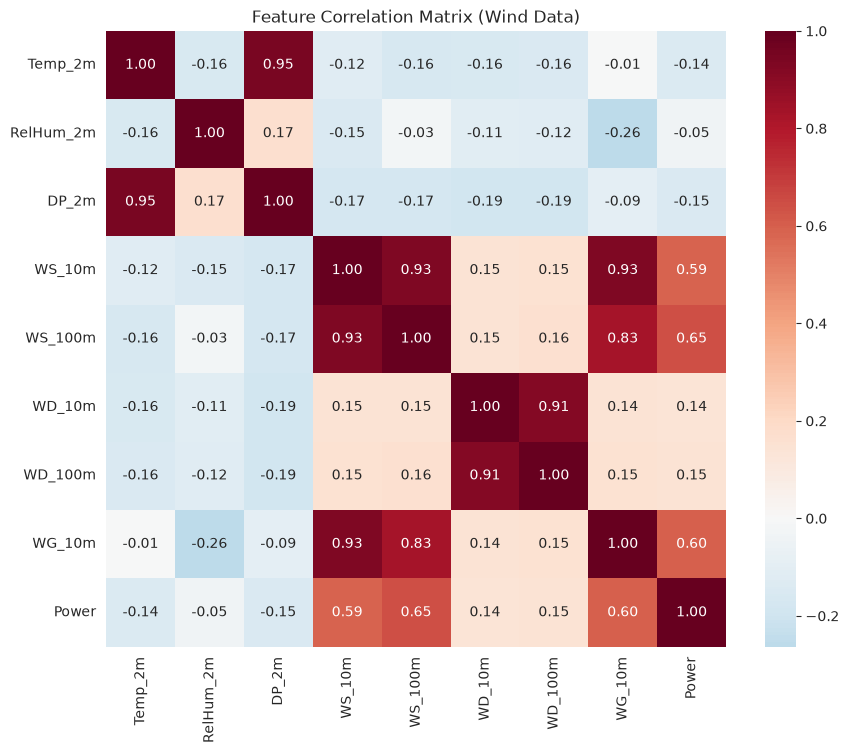


=== TOP FEATURES CORRELATED WITH POWER ===
WS_100m      0.648089
WG_10m       0.597449
WS_10m       0.591892
WD_100m      0.146490
WD_10m       0.137666
RelHum_2m   -0.045171
Temp_2m     -0.142244
DP_2m       -0.152323
Name: Power, dtype: float64

=== OUTLIER DETECTION (IQR method) ===
WS_10m: 1913 outliers (1.4%)
WS_100m: 1369 outliers (1.0%)
WG_10m: 1701 outliers (1.2%)
Temp_2m: 46 outliers (0.0%)

Plan: Outliers in wind speed/gust are natural extreme weather events.


In [17]:
# === EDA: Wind Power ===

# Drop unnamed index
df = df_wind.drop(columns=['Unnamed: 0'], errors='ignore')

# --- 1. Target column ---
print("=== TARGET: Power ===")
print(f"Power represents normalized turbine power output (0 = no gen, 1 = max)")
print(f"Type: Continuous (Regression problem)")
print(df['Power'].describe())

# Target distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Power'], bins=60, kde=True)
plt.title('Distribution of Power (Target)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Power'])
plt.title('Boxplot of Power')
plt.tight_layout()
plt.show()

# --- 2. Feature types ---
categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical features ({len(categorical)}): {categorical}")
print(f"Numerical features ({len(numerical)}): {numerical}")
# Location is stored as int but is categorical
location_cat = df['Location'].nunique()
print(f"  → Location has {location_cat} unique values, treat as categorical")

# --- 3. Null values ---
print(f"\n=== NULL VALUES ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No null values in any column!")

# --- 4. Correlation with target ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Location', errors='ignore')
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix (Wind Data)')
plt.show()

# Top correlations with Power
print("\n=== TOP FEATURES CORRELATED WITH POWER ===")
power_corr = corr['Power'].drop('Power').sort_values(ascending=False)
print(power_corr)

# --- 5. Outliers ---
print(f"\n=== OUTLIER DETECTION (IQR method) ===")
for col in ['WS_10m', 'WS_100m', 'WG_10m', 'Temp_2m']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({(outliers/len(df)*100):.1f}%)")

print("\nPlan: Outliers in wind speed/gust are natural extreme weather events.")

# Topic 2 : Solar Plant Energy Output Analysis

## Problem Statement

Solar energy output varies significantly with weather conditions, panel degradation, and inverter efficiency. Understanding these factors can help plant operators optimize maintenance schedules and improve energy yield predictions.

**Goal:** Build a regression model to predict AC power output of solar panels using generation metrics and weather sensor data.

**Approach:**
- Merge inverter-level generation data with weather sensor data
- Analyze how DC power, temperature, and irradiation affect AC output
- Engineer features from timestamp (hour, time of day)
- Train regression models to predict AC_POWER
- Evaluate using RMSE, MAE, R²

**Audience:** Solar farm operators, renewable energy analysts, maintenance teams

## Data Info
**Source:** Kaggle - Solar Power Generation Data (2 solar plants)
**Generation data:** 68,778 rows (Plant 1) + 67,698 rows (Plant 2) — inverter-level readings
**Weather data:** 3,182 rows (Plant 1) + 3,259 rows (Plant 2) — 15-min sensor readings
**Merged dataset:** ~68,778 rows × 13 columns (after joining on timestamp + plant)
**Target Variable:** `AC_POWER` — AC power output (continuous, range 0–1411)
**Problem Type:** Regression
**Data Frequency:** ~15-min intervals over ~34 days per plant

## Data Dictionary
| Column               | Type    | Description                                              |
| -------------------- | ------- | -------------------------------------------------------- |
| DATE_TIME            | datetime| Timestamp of reading                                     |
| PLANT_ID             | int     | Plant identifier (4135001 = Plant 1, 4136001 = Plant 2)  |
| SOURCE_KEY           | object  | Inverter/sensor identifier (categorical)                 |
| DC_POWER             | float   | DC power generated (kW)                                  |
| **AC_POWER**         | float   | **TARGET:** AC power output (kW)                         |
| DAILY_YIELD          | float   | Cumulative daily energy yield (kWh)                      |
| TOTAL_YIELD          | float   | Cumulative total energy yield (kWh)                      |
| AMBIENT_TEMPERATURE  | float   | Outside air temperature (°C)                             |
| MODULE_TEMPERATURE   | float   | Solar panel temperature (°C)                             |
| IRRADIATION          | float   | Solar irradiance (W/m²)                                  |

In [18]:
# ═══════════════════════════════════════════════
# TOPIC 2: Solar Plant Energy Output Analysis
# ═══════════════════════════════════════════════

BASE_SOLAR = '/home/ultori/Downloads/motor Datasets/plants/archive(2)'

# Load generation + weather data
df_gen = pd.read_csv(f'{BASE_SOLAR}/Plant_1_Generation_Data.csv')
df_wth = pd.read_csv(f'{BASE_SOLAR}/Plant_1_Weather_Sensor_Data.csv')

# Parse dates: generation uses DD-MM-YYYY, weather uses YYYY-MM-DD
df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'], format='%d-%m-%Y %H:%M')
df_wth['DATE_TIME'] = pd.to_datetime(df_wth['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Round generation to 15-min to align with weather sensor readings
df_gen['TIME_15'] = df_gen['DATE_TIME'].dt.round('15min')

# Merge on rounded time
df_solar = pd.merge(df_gen, df_wth,
                    left_on=['TIME_15', 'PLANT_ID'],
                    right_on=['DATE_TIME', 'PLANT_ID'],
                    how='left', suffixes=('_gen', '_wth'))

df_solar.drop(columns=['TIME_15', 'DATE_TIME_wth'], inplace=True, errors='ignore')
print(f'Merged shape: {df_solar.shape}')
df_solar.head(10)

Merged shape: (68778, 11)


,DATE_TIME_gen,PLANT_ID,SOURCE_KEY_gen,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_wth,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
5,2020-05-15,4135001,VHMLBKoKgIrUVDU,0.0,0.0,0.0,7206408.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
6,2020-05-15,4135001,WRmjgnKYAwPKWDb,0.0,0.0,0.0,7028673.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
7,2020-05-15,4135001,ZnxXDlPa8U1GXgE,0.0,0.0,0.0,6522172.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
8,2020-05-15,4135001,ZoEaEvLYb1n2sOq,0.0,0.0,0.0,7098099.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
9,2020-05-15,4135001,adLQvlD726eNBSB,0.0,0.0,0.0,6271355.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


=== TARGET: AC_POWER ===
AC_POWER is the AC power output in kW — continuous, regression target
count    68778.000000
mean       307.802752
std        394.396439
min          0.000000
25%          0.000000
50%         41.493750
75%        623.618750
max       1410.950000
Name: AC_POWER, dtype: float64


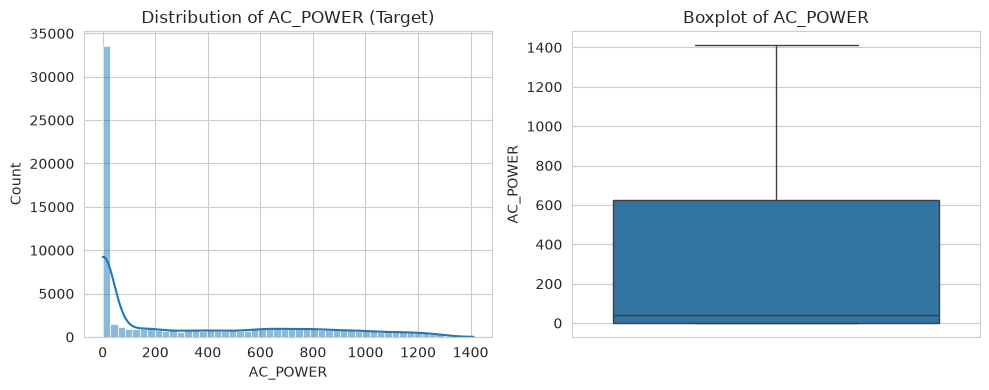

/tmp/ipykernel_20247/2184245744.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_solar.select_dtypes(include=['object', 'category']).columns.tolist()



Categorical features (2): ['SOURCE_KEY_gen', 'SOURCE_KEY_wth']
Numerical features (8): ['PLANT_ID', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

=== NULL VALUES ===
SOURCE_KEY_wth         4
AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
dtype: int64

Plan: Only 4 rows with null weather data (edge of date range) — drop or backfill.


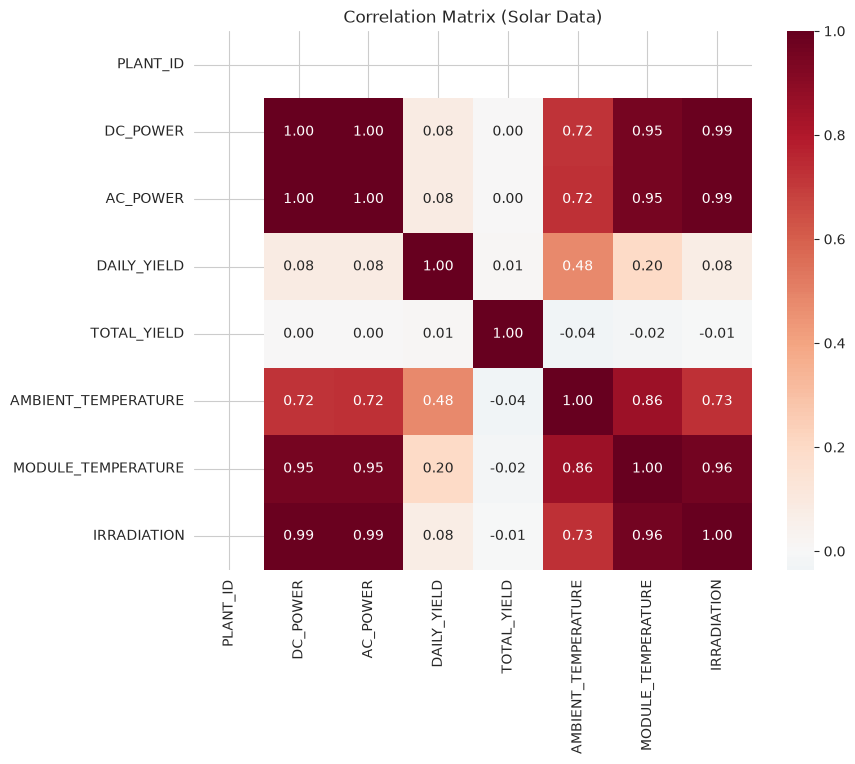


=== TOP FEATURES CORRELATED WITH AC_POWER ===
DC_POWER               0.999996
IRRADIATION            0.989340
MODULE_TEMPERATURE     0.954924
AMBIENT_TEMPERATURE    0.724903
DAILY_YIELD            0.082234
TOTAL_YIELD            0.003804
PLANT_ID                    NaN
Name: AC_POWER, dtype: float64

=== OUTLIER CHECK ===
DC_POWER: 0 outliers (0.0%)
AC_POWER: 0 outliers (0.0%)
DAILY_YIELD: 0 outliers (0.0%)
AMBIENT_TEMPERATURE: 0 outliers (0.0%)
IRRADIATION: 44 outliers (0.1%)

Plan: Outliers in power (irradiation) likely from peak sun hours — keep as signal.


In [19]:
# === EDA: Solar Power ===

# --- 1. Target column ---
print("=== TARGET: AC_POWER ===")
print("AC_POWER is the AC power output in kW — continuous, regression target")
print(df_solar['AC_POWER'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_solar['AC_POWER'], bins=50, kde=True)
plt.title('Distribution of AC_POWER (Target)')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_solar['AC_POWER'])
plt.title('Boxplot of AC_POWER')
plt.tight_layout()
plt.show()

# --- 2. Feature types ---
cat_cols = df_solar.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_solar.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features ({len(num_cols)}): {num_cols}")

# --- 3. Null values ---
print(f"\n=== NULL VALUES ===")
nulls = df_solar.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No null values!")
if nulls.any():
    print("\nPlan: Only 4 rows with null weather data (edge of date range) — drop or backfill.")

# --- 4. Correlation with target ---
num_df = df_solar.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix (Solar Data)')
plt.show()

print("\n=== TOP FEATURES CORRELATED WITH AC_POWER ===")
ac_corr = corr['AC_POWER'].drop('AC_POWER').sort_values(ascending=False)
print(ac_corr)

# --- 5. Outliers ---
print(f"\n=== OUTLIER CHECK ===")
for col in ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'IRRADIATION']:
    if col in df_solar.columns:
        Q1 = df_solar[col].quantile(0.25)
        Q3 = df_solar[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df_solar[col] < Q1 - 1.5*IQR) | (df_solar[col] > Q3 + 1.5*IQR)).sum()
        print(f"{col}: {outliers} outliers ({(outliers/len(df_solar)*100):.1f}%)")

print("\nPlan: Outliers in power (irradiation) likely from peak sun hours — keep as signal.")

# Topic 3 : Predictive Maintenance for Air Compressors

## Problem Statement

Industrial air compressors require regular maintenance to prevent unexpected failures. By monitoring sensor data (temperature, pressure, motor current, etc.), we can predict anomalies and schedule proactive maintenance, reducing downtime and repair costs.

**Goal:** Build a classification model to predict compressor operational status (COMP = 0 failure / 1 normal) and identify key sensor indicators preceding failures.

**Approach:**
- Explore sensor time-series data for patterns preceding status changes
- Handle class imbalance (COMP=1 is dominant)
- Engineer lag/rolling features from sensor readings
- Train classification models (Logistic Regression, Random Forest, XGBoost)
- Evaluate with precision, recall, F1-score, ROC-AUC

**Audience:** Industrial maintenance teams, plant reliability engineers, operations managers

## Data Info
**Source:** MetroPT3 Air Compressor Dataset (Kaggle / UCI)
**Rows:** ~1,516,948
**Columns:** 17 (16 features + 1 unnamed index)
**Target Variable:** `COMP` — compressor state (0 = anomalous/failure, 1 = normal)
**Problem Type:** Binary Classification (imbalanced)
**Data Frequency:** 10-second intervals across ~7 months
**Note:** 1.5M+ rows far exceed the 15k minimum; all 16 feature columns are numeric

## Data Dictionary
| Column            | Type    | Description                                           |
| ----------------- | ------- | ----------------------------------------------------- |
| timestamp         | datetime| Timestamp (10-second intervals)                       |
| TP2               | float   | Temperature sensor 2 (°C)                             |
| TP3               | float   | Temperature sensor 3 (°C)                             |
| H1                | float   | Temperature at sensor H1 (°C)                         |
| DV_pressure       | float   | Differential vibration pressure                       |
| Reservoirs        | float   | Reservoir pressure                                   |
| Oil_temperature   | float   | Oil temperature (°C)                                  |
| Motor_current     | float   | Motor current (A)                                     |
| **COMP**          | float   | **TARGET:** Compressor state (0=failure, 1=normal)    |
| DV_eletric        | float   | Electric differential                                 |
| Towers            | float   | Tower pressure                                        |
| MPG               | float   | Main pressure gauge                                   |
| LPS               | float   | Low-pressure sensor                                   |
| Pressure_switch   | float   | Pressure switch state (binary)                        |
| Oil_level         | float   | Oil level indicator (binary)                          |
| Caudal_impulses   | float   | Flow impulses (binary)                                |

In [20]:
# ═══════════════════════════════════════════════
# TOPIC 3: Predictive Maintenance for Compressors
# ═══════════════════════════════════════════════

BASE_COMP = '/home/ultori/Downloads/motor Datasets/compressor'

# Load a sample (full 1.5M rows may be slow; use 500k for EDA)
df_comp = pd.read_csv(f'{BASE_COMP}/MetroPT3(AirCompressor).csv')
df_comp.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(f'Shape: {df_comp.shape}')
df_comp.head(10)

Shape: (1516948, 16)


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
5,2020-02-01 00:00:49,-0.012,9.306,9.290,-0.024,9.308,53.500,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
6,2020-02-01 00:00:59,-0.012,9.296,9.280,-0.024,9.298,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
7,2020-02-01 00:01:09,-0.014,9.286,9.270,-0.024,9.286,53.550,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
8,2020-02-01 00:01:19,-0.012,9.276,9.258,-0.022,9.276,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
9,2020-02-01 00:01:29,-0.012,9.264,9.248,-0.022,9.264,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


=== TARGET: COMP ===
COMP = compressor state (0 = anomalous/failure, 1 = normal)
This is a Binary Classification problem (imbalanced)

Value counts:
COMP
1.0    1269620
0.0     247328
Name: count, dtype: int64

Class balance: COMP
1.0    0.837
0.0    0.163
Name: proportion, dtype: float64


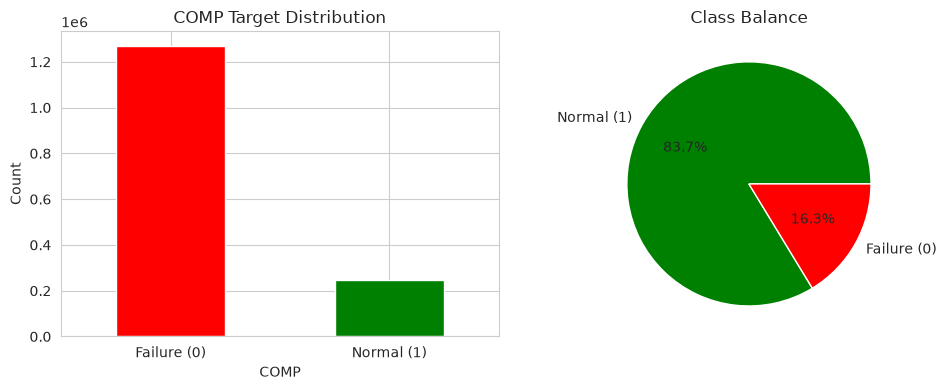

/tmp/ipykernel_20247/3075696400.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_comp.select_dtypes(include=['object', 'category']).columns.tolist()



Categorical (1): ['timestamp']
Numerical (15): ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

=== NULL VALUES ===
No null values in any column!


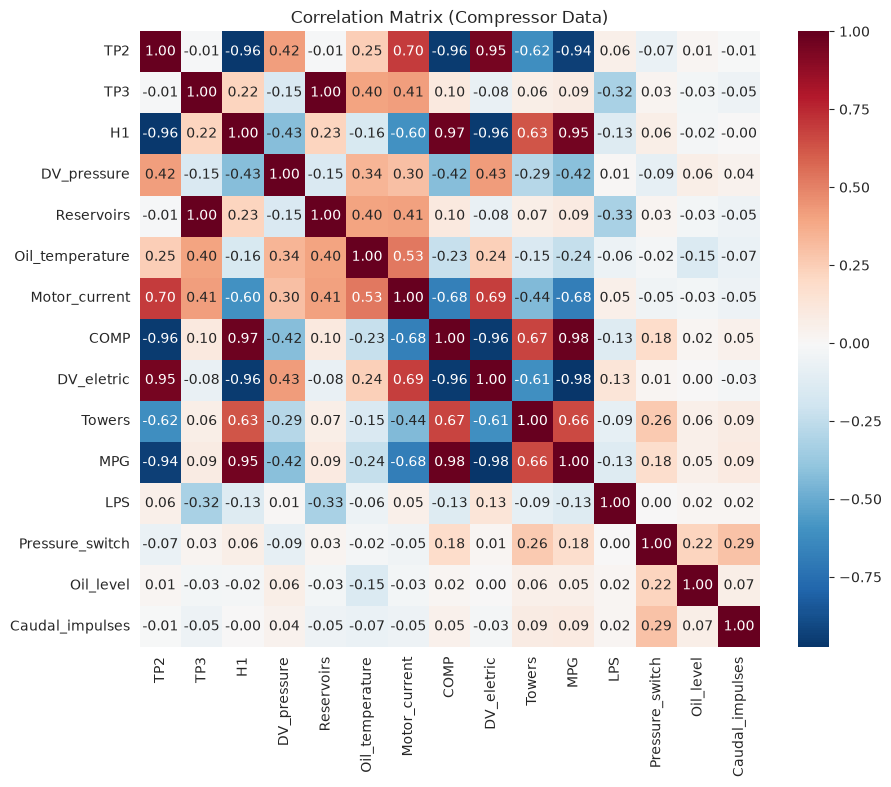


=== TOP FEATURES CORRELATED WITH COMP ===
MPG                0.984555
H1                 0.971419
Towers             0.668804
Pressure_switch    0.183160
Reservoirs         0.104509
TP3                0.103295
Caudal_impulses    0.050725
Oil_level          0.017974
LPS               -0.132727
Oil_temperature   -0.233677
DV_pressure       -0.423992
Motor_current     -0.681326
TP2               -0.955521
DV_eletric        -0.959307
Name: COMP, dtype: float64

=== OUTLIER CHECK (key sensors) ===
TP2: 269592 outliers (17.8%)
TP3: 4518 outliers (0.3%)
Oil_temperature: 5194 outliers (0.3%)
Motor_current: 0 outliers (0.0%)

Plan: Outliers may indicate actual failure events — important signal!
Keep outliers


In [21]:
# === EDA: Compressor Predictive Maintenance ===

# --- 1. Target column ---
print("=== TARGET: COMP ===")
print("COMP = compressor state (0 = anomalous/failure, 1 = normal)")
print("This is a Binary Classification problem (imbalanced)")

print(f"\nValue counts:")
print(df_comp['COMP'].value_counts())
print(f"\nClass balance: {df_comp['COMP'].value_counts(normalize=True).round(3)}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df_comp['COMP'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.xticks([0, 1], ['Failure (0)', 'Normal (1)'], rotation=0)
plt.title('COMP Target Distribution')
plt.ylabel('Count')
plt.subplot(1, 2, 2)
df_comp['COMP'].value_counts(normalize=True).plot(kind='pie', 
    labels=['Normal (1)', 'Failure (0)'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Class Balance')
plt.tight_layout()
plt.show()

# --- 2. Feature types ---
cat_cols = df_comp.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_comp.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical ({len(cat_cols)}): {cat_cols}")
print(f"Numerical ({len(num_cols)}): {num_cols}")

# --- 3. Null values ---
print(f"\n=== NULL VALUES ===")
nulls = df_comp.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "No null values in any column!")

# --- 4. Correlation ---
num_df = df_comp.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix (Compressor Data)')
plt.show()

print("\n=== TOP FEATURES CORRELATED WITH COMP ===")
comp_corr = corr['COMP'].drop('COMP', errors='ignore').sort_values(ascending=False)
print(comp_corr)

# --- 5. Outliers ---
print(f"\n=== OUTLIER CHECK (key sensors) ===")
for col in ['TP2', 'TP3', 'Oil_temperature', 'Motor_current']:
    Q1 = df_comp[col].quantile(0.25)
    Q3 = df_comp[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_comp[col] < Q1 - 1.5*IQR) | (df_comp[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({(outliers/len(df_comp)*100):.1f}%)")

print("\nPlan: Outliers may indicate actual failure events — important signal!")
print("Keep outliers")